## Insert num. of bars into metadata

In [2]:
import json

with open('lead_sheet_chords.json', 'r') as f:
  progressions = json.load(f)

changes = {x['title'].lower(): x['chord_changes'] for x in progressions}

with open('metadata.json', 'r') as f:
  metadata = json.load(f)

for item in metadata:
  if item['standard'].lower() not in changes:
    continue
  if changes[item['standard'].lower()] == None:
    continue
  item['num_bars'] = len(changes[item['standard'].lower()])

with open('metadata.json', 'w') as f:
  json.dump(metadata, f, indent=2)

## Insert default key info into metadata

In [ ]:
import json

with open('chord_progressions_0614.json', 'r') as f:
  progression_data = json.load(f)

changes = {x['title'].lower(): x['key'] for x in progression_data}
changes

{'airegin': 'Ab-maj',
 'all the things you are': 'Ab-maj',
 'alone together': 'D-maj',
 'along came betty': 'Ab-maj',
 'anthropology': 'Bb-maj',
 "bag's groove": 'F-maj',
 "bessie's blues": 'Eb-maj',
 "billie's bounce": 'F-maj',
 'blue train': 'Eb-maj',
 'blues by five': 'Bb-maj',
 'blues for alice': 'F-maj',
 'blues in the closet': 'Bb-maj',
 'bye bye blackbird': 'G-maj',
 'caravan': 'C-maj',
 'cherokee': 'Bb-maj',
 'confirmation': 'F-maj',
 'countdown': 'Bb-maj',
 'desafinado': 'F-maj',
 'dolphin dance': None,
 "don't get around much anymore": 'C-maj',
 'donna lee': 'Ab-maj',
 'e.s.p.': 'F-maj',
 'embraceable you': 'F-maj',
 'footprints': 'C-min',
 'giant steps': 'Eb-maj',
 'good bait': 'Bb-maj',
 "groovin' high": 'Db-maj',
 'honeysuckle rose': 'F-maj',
 'hot house': 'C-maj',
 'how deep is the ocean': 'C-min',
 'how high the moon': 'G-maj',
 "i can't get started": 'C-maj',
 'i got rhythm': 'Bb-maj',
 'i mean you': 'F-maj',
 "i'll remember april": 'G-maj',
 'if i were a bell': 'F-maj'

In [ ]:
with open('metadata.json', 'r') as f:
  metadata = json.load(f)

for item in metadata:
  if item['standard'].lower() not in changes:
    continue
  if changes[item['standard'].lower()] == None:
    continue
  item['key'] = changes[item['standard'].lower()].replace('-', ' ')

with open('metadata.json', 'w') as f:
  json.dump(metadata, f, indent=2)

In [1]:
import json
import math
from pathlib import Path
import numpy as np
import pandas as pd
import dtw
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

from jsd.chords import parse_wjd_chord, parse_cace_chord, transpose_wjd_chord_string
from jsd import dtw_utils

DIST_FN = 'cosine'

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [2]:
with open("metadata_0614.json", "r") as f:
  metadata = json.load(f)

with open("chord_progressions_0614.json", "r") as f:
  chord_progressions = json.load(f)

  0%|          | 0/302 [00:00<?, ?it/s]

Transposing:   0%|          | 0/11 [00:00<?, ?it/s]

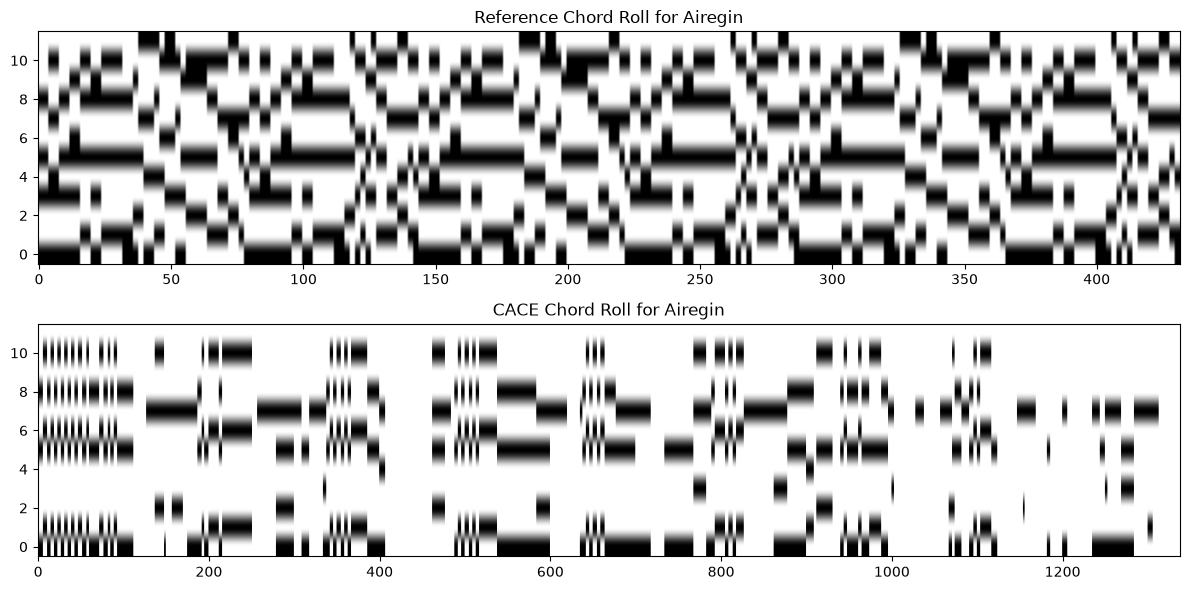

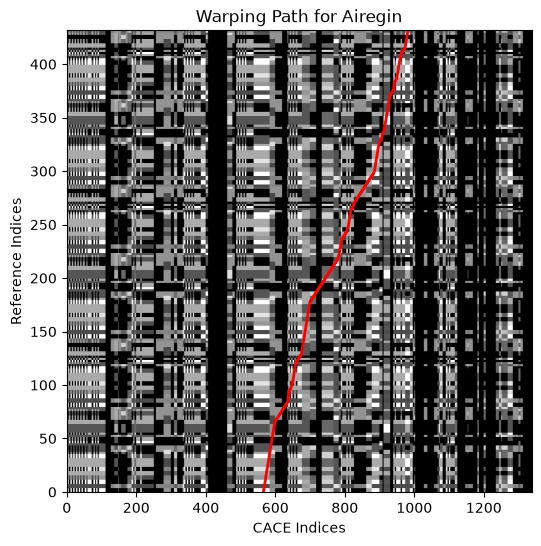

In [5]:
def get_reference_roll(progression: list[str], beat_length: int) -> tuple[np.ndarray, dict[int, str]]:
  chords = " ".join([x.strip() for x in progression])
  chords = chords.split(" ")

  for i, chord in enumerate(chords):
    if chord == "%":
      chords[i] = chords[i-1]

  beat_notes = []
  for chord in chords:
    root, quality, _, extensions = parse_wjd_chord(chord)
    if root is None:
      beat_notes.append([])
      continue
    notes = [root] + [root + x for x in quality]
    notes += [root + x for x in extensions] if extensions is not None else []
    notes = list(set(n % 12 for n in notes))
    beat_notes.append(notes)

  roll = np.zeros((beat_length * len(beat_notes), 12), dtype=np.float32)
  for i, notes in enumerate(beat_notes):
    for note in notes:
      roll[i*beat_length:(i+1)*beat_length, note] = 1.0

  chord_timeframes = {}
  for i, notes in enumerate(beat_notes):
    chord_timeframes[i * beat_length] = chords[i]

  return roll, chord_timeframes


def get_cace_roll(cace_chords: pd.DataFrame, total_length: float) -> np.ndarray:
  len_roll = math.ceil(total_length * 5)
  roll = np.zeros((len_roll, 12), dtype=np.float32)
  for _, row in cace_chords.iterrows():
    start = int(row['start'] * 5)
    end = int(row['end'] * 5)
    chord = row['chord']

    root, quality, _, extensions = parse_cace_chord(chord)

    if root is None:
      continue

    notes = [root]
    notes += [root + x for x in quality] if quality is not None else []
    notes += [root + x for x in extensions] if extensions is not None else []
    notes = list(set(n % 12 for n in notes))

    roll[start:end, notes] = 1.0
  return roll


for entry in tqdm(metadata):
  # skip if output file already exists
  # if Path(f"chords/{entry['yt_id']}.csv").exists():
  #   continue

  with open(entry['files']['beats'], "r") as f:
    beats = [float(line.strip()) for line in f]

  with open(entry['files']['cace_chords'], "r") as f:
    cace_chords = pd.read_csv(f, sep="\t", header=None, names=["start", "end", "chord"])

  reference_chords = next((e for e in chord_progressions if e['title'] == entry['standard']), None)
  if reference_chords is None:
    print(f"No matching entry found for {entry['standard']}")
    exit()
  reference_chords = reference_chords['chord_changes']

  beat_length = np.mean(np.diff(beats))
  num_repeats = min(entry['audio_length'] // (len(reference_chords) * 4 * beat_length), 2)

  reference_chords = reference_chords * int(num_repeats + 1)
  timescale = round(entry['audio_length'] / (len(reference_chords) * 5 * beat_length))

  reference_roll, reference_frames = get_reference_roll(reference_chords, timescale)
  cace_roll = get_cace_roll(cace_chords, entry['audio_length'])

  fix, ax = plt.subplots(2, 1, figsize=(12, 6))
  ax[0].imshow(reference_roll.T, aspect='auto', origin='lower', cmap='gray_r')
  ax[0].set_title(f"Reference Chord Roll for {entry['standard']}")
  ax[1].imshow(cace_roll.T, aspect='auto', origin='lower', cmap='gray_r')
  ax[1].set_title(f"CACE Chord Roll for {entry['standard']}")
  plt.tight_layout()

  best_dist = float('inf')
  best_reference_indices = None
  best_cace_indices = None
  best_transpose = 0

  try:
    for i in tqdm(range(0, 11), leave=False, desc="Transposing"):
      D, C, D1, warp_path = dtw_utils.accelerated_dtw(
        reference_roll,
        cace_roll,
        dist=DIST_FN
      )

      step_pattern = dtw.rabinerJuangStepPattern(2, slope_weighting='c')
      alignment = dtw.dtw(
        x = C,
        step_pattern=step_pattern,
        open_begin=True,
        open_end=True
      )

      dist = alignment.normalizedDistance
      if dist < best_dist:
        best_dist = dist
        best_reference_indices = alignment.index1
        best_cace_indices = alignment.index2
        best_transpose = i
  except Exception as e:
    print(f"Error processing {entry['yt_id']}: {e}")
    continue

  # draw warping path
  plt.figure(figsize=(6, 6))
  plt.imshow(C, aspect='auto', origin='lower', cmap='gray_r')
  plt.plot(best_cace_indices, best_reference_indices, 'r-', linewidth=2)
  plt.xlabel('CACE Indices')
  plt.ylabel('Reference Indices')
  plt.title(f'Warping Path for {entry["standard"]}')
  plt.show()

  break

  chord_df = []
  for ref_idx, cace_idx in zip(best_reference_indices, best_cace_indices):
    if ref_idx in reference_frames:
      chord_df.append({
        'time': cace_idx / 5.0,
        'chord': transpose_wjd_chord_string(reference_frames[ref_idx], best_transpose)
      })

  chord_df = pd.DataFrame(chord_df)
  chord_df.to_csv(f"chords/{entry['yt_id']}.csv", index=False)

In [20]:
import json

with open("chord_progressions_0614.json", "r") as f:
  chord_progressions = json.load(f)

standards = set(e['title'] for e in chord_progressions)

with open("metadata.json", "r") as f:
  metadata = json.load(f)

metadata = [e for e in metadata if e['standard'] in standards]

with open("metadata_0614.json", "w") as f:
  json.dump(metadata, f, indent=2)